In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from tqdm.auto import tqdm

import multiprocessing
multiprocessing.set_start_method('spawn', True)

# VAE 모델 정의
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 128)  # Mean
        self.fc2 = nn.Linear(64 * 56 * 56, 128)  # Log Var
        self.fc3 = nn.Linear(128, 64 * 56 * 56)  # Decoder input

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)

    def encode(self, x):
        h1 = F.relu(self.conv1(x))
        h2 = F.relu(self.conv2(h1))
        h3 = h2.view(h2.size(0), -1)  # Flatten
        return self.fc1(h3), self.fc2(h3)  # Mean and log variance

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Standard deviation
        eps = torch.randn_like(std)  # Random noise
        return mu + eps * std

    def decode(self, z):
        h3 = self.fc3(z).view(-1, 64, 56, 56)  # Reshape
        h4 = F.relu(self.deconv1(h3))
        return torch.sigmoid(self.deconv2(h4))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

    def loss_function(self, recon_x, x, mu, logvar, beta=0.001):
        if 0:
            MSE = F.mse_loss(recon_x, x)  # Reconstruction loss
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence
            return MSE + KLD * beta
        else:
            MSE = F.mse_loss(recon_x, x, reduction='sum')
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            # Divide by batch size
            MSE /= x.size(0)
            KLD /= x.size(0)
            return MSE + KLD


def frange_cycle_linear(n_iter, start=0.0, stop=100.0,  n_cycle=4, ratio=0.5):
    L = np.ones(n_iter) * stop
    period = n_iter/n_cycle
    step = (stop-start)/(period*ratio) # linear schedule

    for c in range(n_cycle):
        v, i = start, 0
        while v <= stop and (int(i+c*period) < n_iter):
            L[int(i+c*period)] = v
            v += step
            i += 1
    return L 

# 데이터셋 로드 및 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# CIFAR-10 데이터셋 예시 사용 (224x224 이미지)
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)


Files already downloaded and verified


In [3]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
# VAE 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training Loop
num_epochs = 10
beta_cyclical = frange_cycle_linear(n_iter=num_epochs, start=0.0, stop=1.0,  n_cycle=4, ratio=0.25)
for epoch in (range(num_epochs)):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(tqdm(train_loader)):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar,z = model(data)
        #loss = model.loss_function(recon_batch, data, mu, logvar, beta=beta_cyclical[epoch])
        loss = model.loss_function(recon_batch, data, mu, logvar, beta=0.001)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}')

  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1, Loss: 95.41537969360351


  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2, Loss: 31.43703432128906


  0%|          | 0/1563 [00:00<?, ?it/s]

...

Epoch 8, Loss: 25.482060002441408


  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 9, Loss: 25.247499907226562


  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 10, Loss: 24.96034887817383


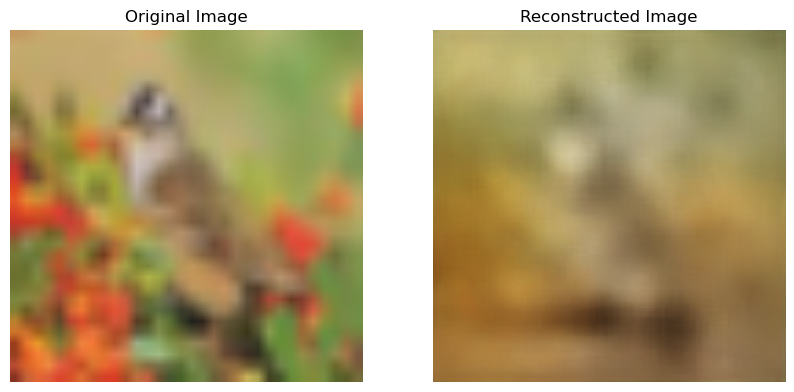

In [4]:
# 테스트(예시로 하나의 이미지 출력)
model.eval()
with torch.no_grad():
    sample_image = data[0].unsqueeze(0).to(device)  # 첫 번째 배치의 첫 번째 이미지
    recon_image, _, _, z = model(sample_image)
    #print(z)

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recon_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

In [46]:
# Add ../ as a directory to import from
import sys
sys.path.append('../')
from src.plant_dataset import PlantDataset, collate_fn

data_aug = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
            ])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    data_aug,
    transforms.ToTensor(),
])

#stages = ["003", "010", "016", "023"]
stages = ["003"]
#train_dataset = PlantDataset("../data/generated_dataset_Sep22_black", stages=stages[0],
train_dataset = PlantDataset("../data/generated_dataset_Sep22_black", stages=stages,plot=["000","001","002"],
                            transform=transform, load_depth=False, preload=True, process_leaf=True, image_size=224)

val_dataset = PlantDataset("../data/generated_dataset_Sep22_black", stages=stages,plot=["003"],
                            transform=transform, load_depth=False, preload=True, process_leaf=True, image_size=224)


Total 1159 images and plant strings loaded
Pre-loading data


  0%|          | 0/1159 [00:00<?, ?it/s]

  4%|▍         | 45/1159 [00:01<00:48, 23.21it/s]


KeyboardInterrupt: 

In [49]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

# VAE 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
num_epochs = 100
best_val_loss = float('inf')
best_model_path = 'vae_best_20241015.pth'

In [44]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# Use pre-trained weights
if 0:
    model.load_state_dict(torch.load(best_model_path))

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _, _) in enumerate(tqdm(train_loader)):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar, _ = model(data)
        loss = model.loss_function(recon_batch, data, mu, logvar) * 0.01
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    train_loss /= len(train_loader.dataset)
    print(f'Epoch {epoch + 1}, Loss: {train_loss}')

    # Validation step
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (data, _, _) in enumerate(tqdm(val_loader)):
            data = data.to(device)
            recon_batch, mu, logvar, _ = model(data)
            loss = model.loss_function(recon_batch, data, mu, logvar) * 0.01
            val_loss += loss.item()

    val_loss /= len(val_loader.dataset)
    print(f'Epoch {epoch + 1}, Validation Loss: {val_loss}')

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f'Saved best model with validation loss: {best_val_loss}')

# 테스트(예시로 하나의 이미지 출력)
model.eval()
with torch.no_grad():
    sample_image = data[0].unsqueeze(0).to(device)  # 첫 번째 배치의 첫 번째 이미지
    recon_image, _, _, _ = model(sample_image)

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recon_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

  0%|          | 0/1208 [00:00<?, ?it/s]

Epoch 1, Loss: 10.426056980519185


  0%|          | 0/397 [00:00<?, ?it/s]

Epoch 1, Validation Loss: 8.146961064143136
Saved best model with validation loss: 8.146961064143136


  0%|          | 0/1208 [00:00<?, ?it/s]

KeyboardInterrupt: 

Total 1535 images and plant strings loaded


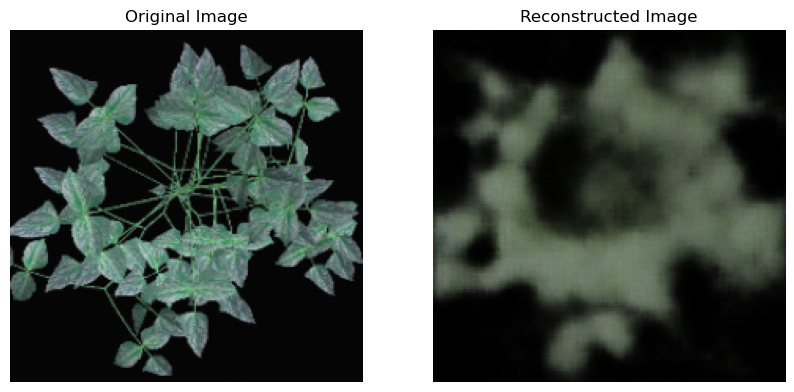

In [58]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    data_aug,
    transforms.ToTensor(),
])

stages = ["003", "010", "016", "023"]
test_dataset = PlantDataset("../data/generated_dataset_Sep22_black", stages=stages,plot=["004"],
                            transform=transform, load_depth=False, preload=False, process_leaf=True, image_size=224)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

# 테스트(예시로 하나의 이미지 출력)
# Load the best model
best_model_path = '../models/checkpoints/vae_best_20241015.pth'
model.load_state_dict(torch.load(best_model_path))
model.eval()

data = next(iter(test_loader))
with torch.no_grad():
    sample_image = data[0].to(device)  # 첫 번째 배치의 첫 번째 이미지
    recon_image, mu, logvar, z = model(sample_image)


# 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recon_image.cpu().squeeze().permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

In [12]:
print(mu.shape)
print(logvar.shape)

torch.Size([1, 128])
torch.Size([1, 128])
